# Experiment 4.0.6 — Raw64 local membrane-memory ablation

Analysis-only notebook. Training is performed by the Slurm arrays documented in `scripts/experiment_4_0_6/README.md`.

Primary question: can stateful Local128 membrane integration recover the Raw64 information that was poorly expressed when `beta_local=0`, without explicit Fixed250 pooling?

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
ART = ROOT / 'notebooks' / 'artifacts' / 'experiment_4_0_6_local_mem_raw64' / 'raw64_local_mem_shift_ablation_v1'
summary = pd.read_csv(ART / 'summary.csv')
effects = pd.read_csv(ART / 'paired_effects_summary.csv')
summary

,condition,variant,hidden_cap,output_cap,valid_count_balanced_accuracy_mean,valid_count_balanced_accuracy_std,hidden_count_linear_balanced_accuracy_mean,hidden_count_linear_balanced_accuracy_std,uend_linear_balanced_accuracy_mean,uend_linear_balanced_accuracy_std,...,state_tail_event_fraction_mean,state_tail_event_fraction_std,output_tail_event_fraction_mean,output_tail_event_fraction_std,local_fraction_at_cap_mean,local_fraction_at_cap_std,state_fraction_at_cap_mean,state_fraction_at_cap_std,output_fraction_at_cap_mean,output_fraction_at_cap_std
0,beta0,binary,1,1,0.201907,0.029776,0.213644,0.026509,0.198346,0.019984,...,0.006637,0.002859,0.006300,0.003111,0.016047,0.001207,2.460359e-02,1.440575e-03,0.029362,0.008072
1,beta0,multi_h,31,1,0.190462,0.035924,0.193053,0.042764,0.201812,0.024121,...,0.144015,0.310708,0.099082,0.212360,0.000000,0.000000,2.302657e-04,5.148897e-04,0.021300,0.014321
2,beta0,multi_ho,31,31,0.289547,0.037988,0.280268,0.032658,0.334245,0.039689,...,0.179886,0.102098,0.172020,0.097150,0.000000,0.000000,3.474850e-06,4.763570e-06,0.000731,0.000707
3,shift234,binary,1,1,0.358236,0.037813,0.356212,0.020889,0.345312,0.041215,...,0.011907,0.002387,0.012230,0.004868,0.027739,0.002491,3.962801e-02,3.506537e-03,0.039653,0.014194
4,shift234,multi_h,31,1,0.345839,0.015619,0.369255,0.012687,0.365589,0.040129,...,0.010683,0.002809,0.009248,0.003412,0.000000,0.000000,0.000000e+00,0.000000e+00,0.041246,0.002848
5,shift234,multi_ho,31,31,0.490703,0.068019,0.480786,0.034006,0.508969,0.083588,...,0.386942,0.150177,0.374736,0.148602,0.000000,0.000000,7.078397e-06,1.345188e-05,0.000485,0.000523
6,shift34,binary,1,1,0.376225,0.045507,0.388905,0.036887,0.380423,0.058314,...,0.015533,0.007144,0.012326,0.007617,0.029493,0.002362,3.900908e-02,9.520529e-03,0.033607,0.013140
7,shift34,multi_h,31,1,0.386533,0.034682,0.383919,0.014057,0.408277,0.065290,...,0.010123,0.002841,0.007585,0.002702,0.000000,0.000000,0.000000e+00,0.000000e+00,0.046705,0.008813
8,shift34,multi_ho,31,31,0.497990,0.047480,0.502100,0.024833,0.544495,0.014334,...,0.232276,0.065397,0.224421,0.065000,0.000000,0.000000,2.728401e-05,3.432467e-05,0.001256,0.001322
9,shift4,binary,1,1,0.364142,0.041323,0.366318,0.041770,0.396113,0.057520,...,0.065817,0.115964,0.088716,0.173105,0.031034,0.002573,4.417818e-02,6.661751e-03,0.035634,0.007321


## Main test BA table
Compare the frozen `beta0` Raw64 baseline against `shift4`, `shift34`, and `shift234` for all three readouts.

In [2]:
cols = [
    'condition', 'variant',
    'valid_count_balanced_accuracy_mean', 'valid_count_balanced_accuracy_std',
    'hidden_count_linear_balanced_accuracy_mean', 'hidden_count_linear_balanced_accuracy_std',
    'uend_linear_balanced_accuracy_mean', 'uend_linear_balanced_accuracy_std',
]
summary[cols].sort_values(['variant', 'condition'])

,condition,variant,valid_count_balanced_accuracy_mean,valid_count_balanced_accuracy_std,hidden_count_linear_balanced_accuracy_mean,hidden_count_linear_balanced_accuracy_std,uend_linear_balanced_accuracy_mean,uend_linear_balanced_accuracy_std
0,beta0,binary,0.201907,0.029776,0.213644,0.026509,0.198346,0.019984
3,shift234,binary,0.358236,0.037813,0.356212,0.020889,0.345312,0.041215
6,shift34,binary,0.376225,0.045507,0.388905,0.036887,0.380423,0.058314
9,shift4,binary,0.364142,0.041323,0.366318,0.041770,0.396113,0.057520
1,beta0,multi_h,0.190462,0.035924,0.193053,0.042764,0.201812,0.024121
4,shift234,multi_h,0.345839,0.015619,0.369255,0.012687,0.365589,0.040129
7,shift34,multi_h,0.386533,0.034682,0.383919,0.014057,0.408277,0.065290
10,shift4,multi_h,0.365118,0.040563,0.374728,0.033001,0.408146,0.016752
2,beta0,multi_ho,0.289547,0.037988,0.280268,0.032658,0.334245,0.039689
5,shift234,multi_ho,0.490703,0.068019,0.480786,0.034006,0.508969,0.083588


## Local-memory effect relative to beta0
The primary effects are `shift4_minus_beta0`, `shift34_minus_beta0`, and `shift234_minus_beta0`.

In [3]:
primary = effects[effects['effect'].isin([
    'shift4_minus_beta0',
    'shift34_minus_beta0',
    'shift234_minus_beta0',
])].copy()
primary.sort_values(['readout', 'variant', 'effect'])

,effect,condition,variant,readout,mean,std,count
24,shift234_minus_beta0,NaN,binary,hidden_whole_count_linear,0.142568,0.038593,5
42,shift34_minus_beta0,NaN,binary,hidden_whole_count_linear,0.175261,0.029560,5
60,shift4_minus_beta0,NaN,binary,hidden_whole_count_linear,0.152674,0.050578,5
27,shift234_minus_beta0,NaN,multi_h,hidden_whole_count_linear,0.176202,0.032061,5
45,shift34_minus_beta0,NaN,multi_h,hidden_whole_count_linear,0.190866,0.047154,5
63,shift4_minus_beta0,NaN,multi_h,hidden_whole_count_linear,0.181676,0.050171,5
30,shift234_minus_beta0,NaN,multi_ho,hidden_whole_count_linear,0.200518,0.063631,5
48,shift34_minus_beta0,NaN,multi_ho,hidden_whole_count_linear,0.221833,0.041313,5
66,shift4_minus_beta0,NaN,multi_ho,hidden_whole_count_linear,0.197296,0.019096,5
25,shift234_minus_beta0,NaN,binary,output_whole_count,0.156328,0.048820,5


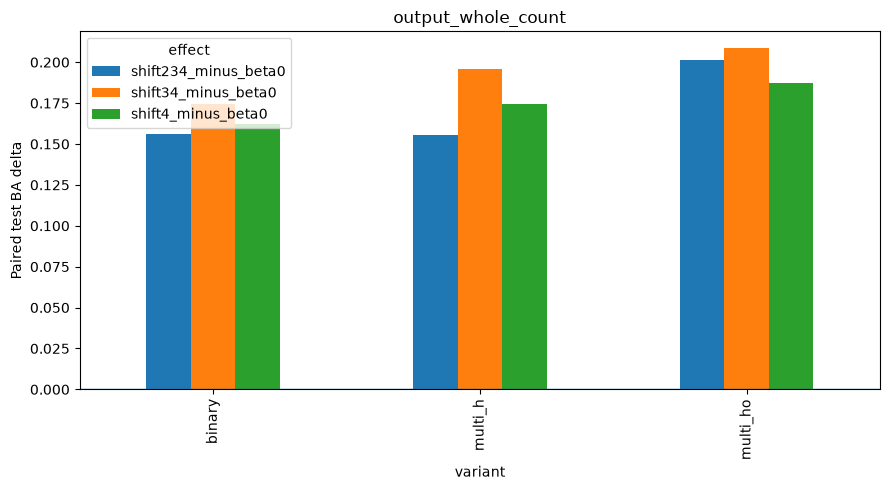

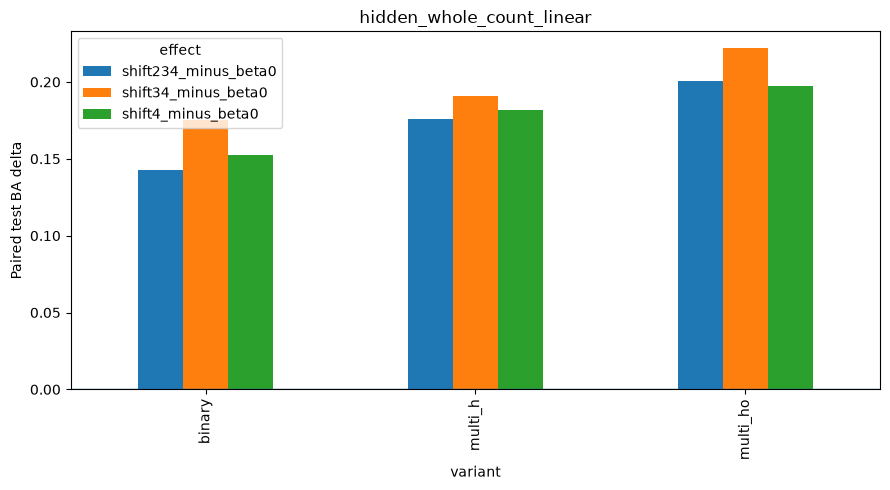

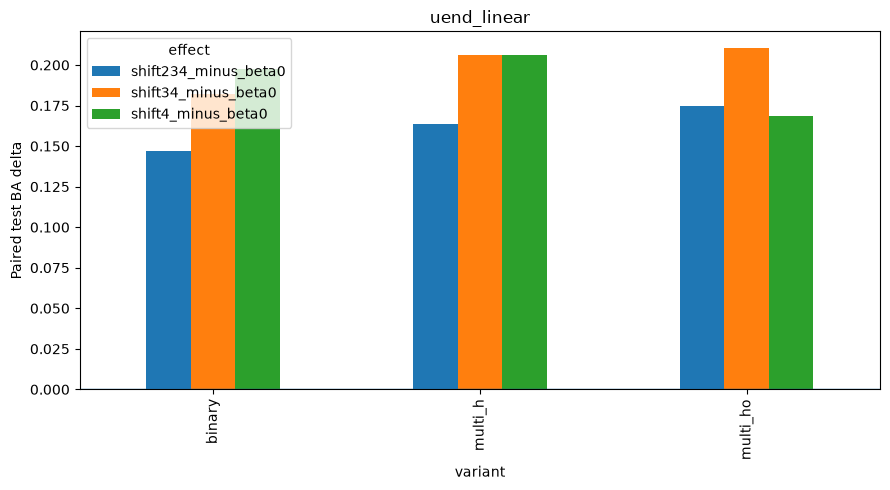

In [4]:
for readout in ['output_whole_count', 'hidden_whole_count_linear', 'uend_linear']:
    view = primary[primary['readout'] == readout].copy()
    pivot = view.pivot(index='variant', columns='effect', values='mean')
    ax = pivot.plot(kind='bar', figsize=(9, 5))
    ax.axhline(0.0, linewidth=1)
    ax.set_ylabel('Paired test BA delta')
    ax.set_title(readout)
    plt.tight_layout()
    plt.show()

## Dynamics diagnostics
Use physical event rates rather than events/timestep because all conditions run Raw64 but the Local membrane distributions differ. Check whether improvements track useful state formation rather than saturation/cap hits.

In [5]:
diag_cols = [
    'condition', 'variant',
    'local_mean_events_per_neuron_second_mean',
    'state_mean_events_per_neuron_second_mean',
    'output_mean_events_per_neuron_second_mean',
    'local_fraction_at_cap_mean',
    'state_fraction_at_cap_mean',
    'output_fraction_at_cap_mean',
    'state_tail_event_fraction_mean',
    'output_tail_event_fraction_mean',
]
summary[diag_cols].sort_values(['variant', 'condition'])

,condition,variant,local_mean_events_per_neuron_second_mean,state_mean_events_per_neuron_second_mean,output_mean_events_per_neuron_second_mean,local_fraction_at_cap_mean,state_fraction_at_cap_mean,output_fraction_at_cap_mean,state_tail_event_fraction_mean,output_tail_event_fraction_mean
0,beta0,binary,1.027016,1.574630,1.879180,0.016047,2.460359e-02,0.029362,0.006637,0.006300
3,shift234,binary,1.775290,2.536192,2.537820,0.027739,3.962801e-02,0.039653,0.011907,0.012230
6,shift34,binary,1.887528,2.496581,2.150849,0.029493,3.900908e-02,0.033607,0.015533,0.012326
9,shift4,binary,1.986191,2.827403,2.280558,0.031034,4.417818e-02,0.035634,0.065817,0.088716
1,beta0,multi_h,1.057454,2.968860,1.363176,0.000000,2.302657e-04,0.021300,0.144015,0.099082
4,shift234,multi_h,1.806940,2.652707,2.639730,0.000000,0.000000e+00,0.041246,0.010683,0.009248
7,shift34,multi_h,1.946916,2.928711,2.989095,0.000000,0.000000e+00,0.046705,0.010123,0.007585
10,shift4,multi_h,1.977509,2.512008,2.520450,0.000000,0.000000e+00,0.039382,0.009742,0.007263
2,beta0,multi_ho,1.432504,23.596727,115.869366,0.000000,3.474850e-06,0.000731,0.179886,0.172020
5,shift234,multi_ho,3.000210,32.615447,159.249708,0.000000,7.078397e-06,0.000485,0.386942,0.374736
